# Laboratorio 2022-23

## Sesión 12: Álgebra lineal y dinámica de poblaciones


En esta sesión vamos a aplicar álgebra lineal elemental para estudiar modelos sencillos que describen cómo evoluciona un población. De la lectura previa conocemos algunos resultados teóricos. Con estos ejercicios comprobaremos la veracidad de estos resultados.

_Advertencia:_ Algunos métodos para matrices, como $\texttt{eigenvectors}\_\texttt{right}$, no funcionan cuando la matriz está definida en RR o CC, los anillos en los que Sagemath trabaja por defecto cuando encuentra números decimales y complejos, respectivamente. Otros métodos, por ejemplo  $\texttt{eigenvalues}$, sí funcionan, pero pueden tener problemas de precisión. Por ello, si vas a usar alguno de estos métodos conviene que definas la matriz en los anillos  QQ (racionales), RDF (Real Double Field) o CDF (Complex Double Field). 

____________

**Ejercicio 1** 

En una población de una determinada especie, los individuos se dividen en dos clases de edad:

- Clase $X$: individuos jóvenes de menos de 1 año. Estos individuos no tienen descendencia, y al cabo del año sobrevive un 60%.
- Clase $Y$: individuos adultos de más de 1 año. Cada uno de estos individuos tiene, en promedio, 3.5 crías cada año. Y al final del año, solo un 20% consigue sobrevivir una temporada más.

Denotamos por $X_n$, $Y_n$ la población de la clase $X$ y de la clase $Y$, respectivamente, en el año $n$. A la vista de los datos, la población de dos años consecutivos está relacionada por una expresión matricial de la forma
$$\left(\begin{array}{c} X_{n+1} \\Y_{n+1} \end{array} \right)= \left(\begin{array}{cc} A & B \\ C & D \end{array} \right)\left(\begin{array}{c} X_{n} \\Y_{n} \end{array} \right).$$



a) Escribir la matriz de transición 
$$M=\left(\begin{array}{cc} A & B \\ C & D \end{array} \right)$$
con los valores correctos de $A$, $B$, $C$ y $D$ para este modelo. 
Comprobar que, aunque no se trata de una matriz de Leslie, tiene un autovalor dominante simple positivo. Determina el autovector normalizado correspondiente al autovalor dominante.

**Nota 1.** Recordar que los autovectores asociados a un autovalor $\lambda$ de una matriz cuadrada $A$ de tamaño $n$, son las soluciones al sistema lineal homogéneo $A-\lambda\cdot I_n=\vec{0}$ (con $I_n$ la matriz identidad de tamaño $n$). Con SageMath podemos obtener el espacio de autovectores asociados a $\lambda$ para una matriz $A$, con 
$$(A-\lambda\texttt{*identity}\_\texttt{matrix}(n))\texttt{.right}\_\texttt{kernel}()$$
y calculamos una **base** (una lista de vectores independientes) del mismo con
$$(A-\lambda\texttt{*identity}\_\texttt{matrix}(n))\texttt{.right}\_\texttt{kernel}()\texttt{.basis}()$$
(como lista, accedemos a cualquiera de sus elementos con la notación *slice*, $[\texttt{j}]$ con $\texttt{j}$ el índice del elemento que nos interese).

**Nota 2.** Si $A$ es una matriz, $A\texttt{.eigenvectors}\_\texttt{right}()$ devuelve una lista de pares $$(\texttt{autovalor, lista de autovectores independientes asociados al autovalor}).$$
En este ejercicio, en el que solo nos interesa uno de los autovalores, trabajar a partir de ella suele resultar más engorroso.

**Nota 3.** En este ejercicio, si el vector inicial de población (que está en el primer cuadrante) es no nulo, necesariamente tiene una componente no nula en la dirección del vector propio asociado al autovalor dominante.

In [1]:
M=matrix(QQ,2,[0,3.5,.6,.2]) # Es importante definir la matriz en QQ para lo que viene después
show(M)

[  0 7/2]
[3/5 1/5]

In [9]:
autovalores=M.eigenvalues()
AbsAutov=[abs(autovalor) for autovalor in autovalores]
dominante=max(AbsAutov) #Valor absoluto del candidato a dominante, lo es si es simple y único en AbsAutov
Dominante=autovalores[AbsAutov.index(dominante)] #Candidato, con su signo, a dominante
simple=bool(dim((M-Dominante*identity_matrix(QQ,M.nrows())).right_kernel())==1)
unico=bool(AbsAutov.count(dominante)==1)
real_positivo=bool(Dominante in RR and Dominante>0)
if  simple and unico and real_positivo:
    print('Existe autovalor dominante, real y positivo, y es: %s'%Dominante)
else:
    print('Esta matriz no tiene valor propio dominante, real y positivo.')

Existe autovalor dominante, real y positivo, y es: 1.552583904633395?


<font style="color: blue;">

> Obsérvese que hemos utilizado $\texttt{identity}\_\texttt{matrix}(\texttt{QQ,M.nrows}())$. Esta es la matriz identidad del mismo tamaño que la **matriz cuadrada** $\texttt{M}$, y definida sobre el cuerpo _exacto_ $\texttt{QQ}$. Esto último es necesario al calcular la dimensión del núcleo que se especifica. Si hiciéramos los cálculos con valores aproximados es bastante probable que este subespacio fuese el trivial $\{\vec0\}$. Aquí necesitamos precisión exacta para evitar esta eventualidad. Una alternativa, sin tomar estas precauciones, es utilizar $\texttt{.eigenvectors}\_\texttt{right}()$, aunque este método no da la información con los autovalores ordenados, de manera que resulta más engorroso.

> Por otra parte, este cálculo del autovalor dominante sigue varios pasos que merece la pena codificar en una función. Codificamos en la siguiente celda la función $\texttt{AutovalorDominante}()$ para este propósito.</font>

In [10]:
def AutovalorDominante(M):
    autovalores=M.eigenvalues()
    AbsAutov=[abs(autovalor) for autovalor in autovalores]
    dominante=max(AbsAutov)##Valor absoluto del candidato a dominante, lo es si es simple y único en AbsAutov
    Dominante=autovalores[AbsAutov.index(dominante)]##Candidato, con su signo, a dominante
    simple=bool(dim((M-Dominante*identity_matrix(QQ,M.nrows())).right_kernel())==1)
    unico=bool(AbsAutov.count(dominante)==1)
    real_positivo=bool(Dominante in RR and Dominante>0)
    if simple and unico and real_positivo:
        return Dominante
    return None#solo se llega aquí si no hay Dominante

In [11]:
Dominante=AutovalorDominante(M)
show(Dominante)

1.552583904633395?

In [12]:
MM=matrix(2,[1,0,0,sqrt(2)])
show(AutovalorDominante(MM))

sqrt(2)

In [13]:
v1=(M-Dominante*identity_matrix(QQ,M.nrows())).right_kernel().basis()[0] #[0] puesto que el método .basis() devuelve una lista
v1=v1/sum(v1)#v1 es un vector, se puede multiplicar por un escalar
print('El vector propio normalizado asociado al valor propio dominante es:')
print(v1)

El vector propio normalizado asociado al valor propio dominante es:
(0.6927148694730984?, 0.3072851305269016?)


<font style="color: blue;">

> Obsérvese que del autovalor $\texttt{Dominante}$ sabemos que es simple, de manera que es seguro que el subespacio asociado tiene dimensión 1 en este caso.
    
> Quizás merezca la pena una función que devuelva, a partir de una matriz, el autovalor dominante (en caso de existir) y su autovector normalizado.

</font>

In [12]:
def DominanteNormalizado(M):
    Dominante=AutovalorDominante(M)
    if Dominante:#Autovalor simple
        v1=(M-Dominante*identity_matrix(QQ,M.nrows())).right_kernel().basis()[0]#[0] puesto que el método .basis() devuelve una lista
        return(Dominante,v1/sum(v1))#v1 es un vector, se puede multiplicar por un escalar
    return(None,None)#solo se llega aquí si no hay Dominante

In [13]:
Dominante,v1=DominanteNormalizado(M)
print('El vector propio normalizado asociado al valor propio dominante es:')
print(v1)

El vector propio normalizado asociado al valor propio dominante es:
(0.6927148694730984?, 0.3072851305269016?)


b) Se parte de un distribución inicial de la población dada por $X_0=10$ e $Y_0=15$. Calcula los valores de $ X_n$ e $Y_n$ para $n= 0, 1, \dots, 50$, y represéntalos gráficamente frente al **tiempo** $n$ en un diagrama de puntos, con un color distinto para cada una de las dos clases de edad.

**Nota:** Para representar en forma de diagrama de puntos, conviene construir listas de pares $(n,X_n)$ y $(n,Y_n)$.

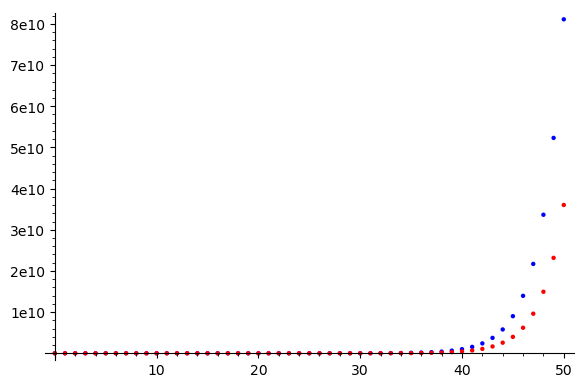

In [28]:
#APARTADO b)
#Para representar en forma de diagrama de puntos, almacenamos pares (n,X_n), (n,Y_n)
PobIn=vector((10,15))
Pob=PobIn
X,Y=[(0,Pob[0])],[(0,Pob[1])]
for j in [1..50]:
    Pob=M*Pob
    X.append((j,Pob[0]))
    Y.append((j,Pob[1]))

points(X,color='blue')+points(Y,color='red')

c) De la lectura previa se sigue que asintóticamente (para $n$ grande} se tienen las leyes de crecimiento 
$$
\frac{X_{n+1}}{X_n}\approx \lambda_1,\qquad \frac{Y_{n+1}}{Y_n}\approx\lambda_1,
$$
donde $\lambda_1$ es el autovalor dominante de $M$. 

Sean $CX_n=\frac{X_{n+1}}{X_{n}} $ y $CY_n=\frac{Y_{n+1}}{Y_{n}}$. Representa gráficamente los pares de puntos $(n,CX_n)$ (en azul) y $(n,CY_n)$ (en rojo) para $ n=0,\dots, 49$, junto con una recta horizontal a altura $\lambda_1$. De acuerdo con la teoría, deberías observar que tanto los puntos azules como los rojos se aproximan a la recta.

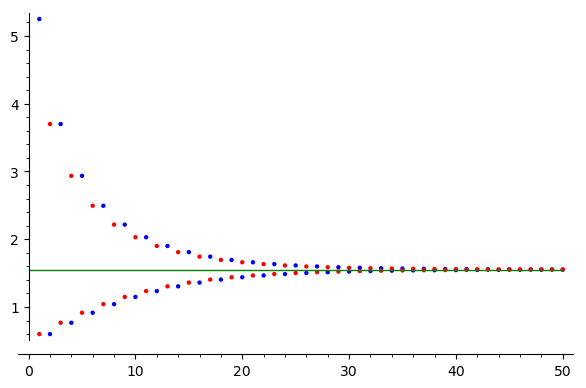

In [16]:
CX=[(j,X[j][1]/X[j-1][1]) for j in xsrange(1,51)] #Lista de pares (j,CX_j))
CY=[(j,Y[j][1]/Y[j-1][1]) for j in xsrange(1,51)] #Lista de pares (j,CY_j))
points(CX,color='blue')+points(CY,color='red')+line([(0,dominante),(50,dominante)],color='green')

In [18]:
#Comparamos el último de los cocientes de cada serie con el autovalor dominante
print(CX[-1][1].n(),CY[-1][1].n(),Dominante.n())
print(CX[-1][1].n()-Dominante.n(),CY[-1][1].n()-Dominante.n())

1.55069408367268 1.55423228998613 1.55258390463340
-0.00188982096071055 0.00164838535273271


d) Las leyes de crecimiento asintóticas indican que para tiempos $n$ grandes 
$$
X_n\approx \alpha \lambda_1^n,\qquad Y_n\approx \beta\lambda_1^n,
$$
donde $\alpha$ y $\beta$ son constantes no negativas que dependen del dato inicial. Compruébalo representando los puntos con escala logarítmica en el eje vertical (se consigue añadiendo la opción $\texttt{scale='semilogy'}$ al comando con el que generes el dibujo, como $\texttt{points}$ o $\texttt{plot}$). Los puntos se dispondrán asintóticamente sobre rectas de pendiente $\log\lambda_1$. Comprueba esta última afirmación. 

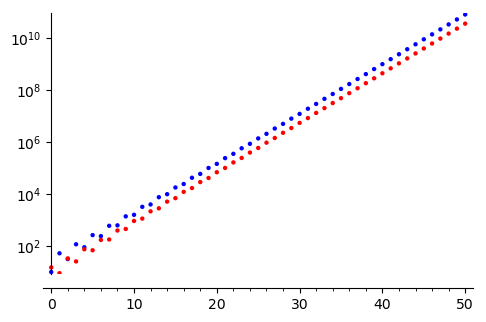

In [21]:
points(X,scale='semilogy',figsize=5)+points(Y,scale='semilogy',color='red')

In [45]:
# Comprobamos que las "pendientes asintóticas" coinciden con el logaritmo del autovalor dominante

pend_x=(log(X[50][1])-log(X[49][1])).n()
pend_y=(log(Y[50][1])-log(Y[49][1])).n()
pend_teor=(log(Dominante).n())
pend_x,pend_y,pend_teor, pend_x-pend_teor,pend_y-pend_teor

(0.438702626618348,
 0.440981719530171,
 0.439920578217555,
 -0.00121795159920718,
 0.00106114131261653)

In [57]:
# También conocemos el valor teórico de alfa y beta. Concretamente, (alfa,beta)=c_1 omega_1, siendo c_1 omega_1+c_2 omega_2 
# la expresión del dato inicial en una base de autovectores (véase la lectura previa). Vamos a obtener estos valores teóricos

# Comenzamos obteniendo la forma de Jordan (en este caso es una matriz diagonal) y la correspondiente matriz de paso
MJordan,Matriz_paso=M2.jordan_form(transformation=True)
show(MJordan) # Vemos que el autovector dominante es el segundo de la base que nos ha dado Sagemath
omega_1=Matriz_paso.column(1) # Este es el autovector correspondiente
omega_1

[-1.352583904633395?|                  0]
[-------------------+-------------------]
[                  0| 1.552583904633395?]

(1, 0.4435954013238272?)

In [64]:
# Obtener alfa y beta es ahora trivial
c_1=(Matriz_paso^(-1)*PobIn)[1]
alfa,beta=c_1*omega_1[0],c_1*omega_1[1]
alfa,beta

(22.72703106365399?, 10.08160646558068?)

In [65]:
# Comprobemos que la ordenada en el origen de las rectas que se obtienen asintóticamente al representar X_n e Y_n en
# escalas logarítmicas coinciden con log(alpha) y log(beta)
ord_x=(log(X[50][1])-50*pend_x).n()
ord_y=(log(Y[50][1])-50*pend_y).n()
ord_x_t=log(alfa).n()
ord_y_t=log(beta).n()
ord_x,ord_x_t,ord_x-ord_x_t,ord_y,ord_y_t,ord_y-ord_y_t

(3.18388535503973,
 3.12355501180812,
 0.0603303432316160,
 2.25814946048335,
 2.31071262153031,
 -0.0525631610469528)

Nuestro siguiente objetivo es comprobar que, según hemos visto en el documento previo, el ritmo de crecimiento asintótico (de ambas clases) no depende del dato inicial. Puesto que el problema es lineal, basta con que comprobemos este hecho para datos iniciales en la intersección de la circunferencia unidad con el primer cuadrante (en el caso de poblaciones solo tienen sentido los datos no negativos):
$$
(X_0,Y_0)=(\cos\theta,\operatorname{sen}\theta),\quad \theta\in(0,\pi/2).
$$

e) Calcula el cociente $CX_{50}(\theta)=\frac{X_{50}(\theta)}{X_{49}(\theta)}$ para $\theta=j\frac\pi{200}$ con $j=1,\dots,99$, siendo $X_n(\theta)$ e $Y_n(\theta)$ las poblaciones en tiempo $n$ en las clases $X$ e $Y$ cuando los datos iniciales son $(X_0,Y_0)=(\cos\theta,\operatorname{sen}\theta)$. Representa la función $CX_{50}(\theta)$ así obtenida. Haz lo mismo para el cociente $CY_{50}(\theta)=\frac{Y_{50}(\theta)}{Y_{49}(\theta)}$.
    
**Nota.** En este apartado se van a utilizar ángulos con coseno o seno próximos a cero. Puesto que se pide dividir por una coordenada que puede ser próxima a cero, conviene trabajar con doble precisión cada vez que se tome un valor inicial de la forma $(\cos\theta,\operatorname{sen}\theta)$. Con $\texttt{vector}(\texttt{RDF},(a,b))$, SageMath toma $a$ y $b$ con doble precisión.

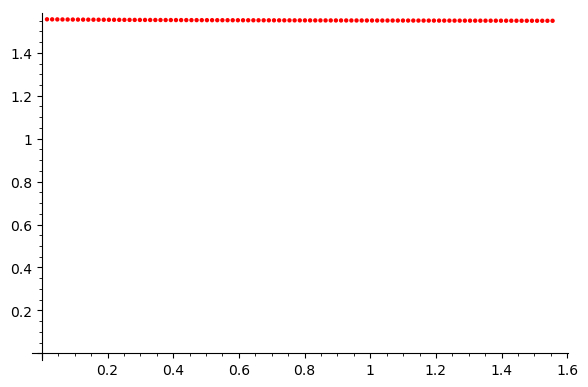

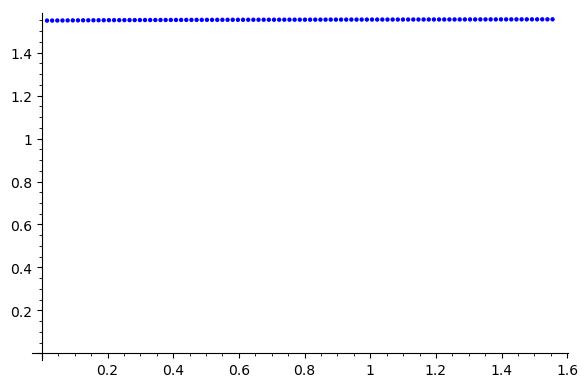

In [71]:
CX,CY=[],[]
for j in [1..99]: #xsrange(101):
    PobIn=vector(RDF,(cos(j*pi/200),sin(j*pi/200)))##Añadimos RDF pues conviene evitar una posible coordenada =0
    Pob49=M^49*PobIn # Como no me interesan las poblaciones intermedias, calculo directamente la población en tiempo 49 
    Pob50=M*Pob49
    cocX=Pob50[0]/Pob49[0]
    cocY=Pob50[1]/Pob49[1]
    CX.append((j*pi/200, cocX))
    CY.append((j*pi/200, cocY))
        
show(points(CX,color='red',xmin=0,xmax=pi/2,ymin=0))
show(points(CY,color='blue',xmin=0,xmax=pi/2,ymin=0))

f) Consideramos los cocientes $TX_n=\frac{X_{n}}{X_n+Y_n}$, $TY_n=\frac{Y_{n}}{X_n+Y_n}$, que nos indican la **proporción** de individuos en cada clase de edad en tiempo $n$. De acuerdo con lo que hemos aprendido en el documento previo, los vectores $(TX_n,TY_n)$ deberían aproximarse asintóticamente al autovector normalizado correspondiente al autovalor dominante $(a,b)$.

Partiendo de una población inicial $X_0=10$, $Y_0=15$, representa gráficamente los pares de puntos $(n,TX_n)$ (en azul) y $(n,TY_n)$ (en azul) para $ n=0,\dots, 49$, junto con rectas horizontales a alturas $a$ y $b$. De acuerdo con la teoría, deberías observar que los puntos azules se acercan a la recta a altura $a$ y los rojos a la recta a altura $b$.

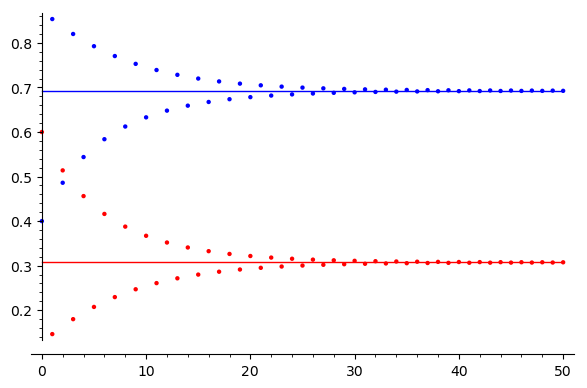

In [72]:
TX=[(j,X[j][1]/(X[j][1]+Y[j][1])) for j in xsrange(51)]
TY=[(j,Y[j][1]/(X[j][1]+Y[j][1])) for j in xsrange(51)]
points(TX,color='blue')+points(TY,color='red')+line([(0,v1[0]),(50,v1[0])],color='blue')+line([(0,v1[1]),(50,v1[1])],color='red')

In [73]:
#Comparamos el último vector (TX,TY) con el autovector normalizado del autovalor dominante
tx,ty=TX[-1][1].n(),TY[-1][1].n()
vector((tx,ty))-v1

(-0.000225921758032821, 0.000225921758032765)

g) Ilustremos ahora la convergencia de la distribución de la población en clases de la que se habla en el apartado anterior de una forma dinámica.  Programa una animación (consultar la función $\texttt{animate}$) en la que se vea cómo, partiendo una vez más de una población inicial $X_0=10$, $Y_0=15$, va cambiando con $n$ el vector cuyas componentes son la proporción de individuos en cada clase de edad en el tiempo $n$, es decir el vector
$$ 
\left(\frac{X(n)}{X(n)+Y(n)}, \frac{Y(n)}{X(n)+Y(n)}\right).
$$


Animation with 51 frames
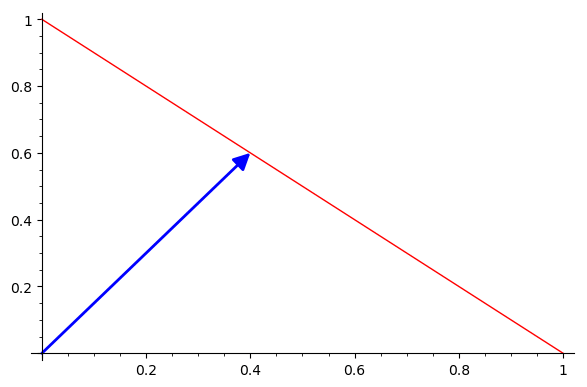

In [69]:
M=matrix(QQ,2,[0,3.5,0.6,0.2])
Pob=vector((10,15))
Peli=[plot(vector(RDF,(Pob[0]/(Pob[0]+Pob[1]),Pob[1]/(Pob[0]+Pob[1]))))+line([(0,1),(1,0)],color='red')]
for k in xsrange(1,51):
    Pob=M*Pob
    w=vector(RDF,(Pob[0]/(Pob[0]+Pob[1]),Pob[1]/(Pob[0]+Pob[1])))
    Fotograma=plot(w)+line([(0,1),(1,0)],color='red')

    Peli.append(Fotograma)

animate(Peli)

In [70]:
##Para guardar la animación como '.gif'
a=animate(Peli)
a.save('peli.gif')

Nuestro siguiente objetivo es comprobar que la proporción límite de individuos en cada clase de edad no depende del dato inicial.  

h) Calcula las proporciones $TX_{50}(\theta)=\frac{X_{50}(\theta)}{X_{50}(\theta)+Y_{50}(\theta)}$ y $TY_{50}(\theta)=\frac{Y_{50}(\theta)}{X_{50}(\theta)+Y_{50}(\theta)}$ para $\theta=j\frac\pi{200}$ con $j=1,\dots,99$, donde $X_n(\theta)$ e $Y_n(\theta)$ tienen el mismo significado que en el apartado d).  Representa las funciones $TX_{50}(\theta)$ y $TY_{50}(\theta)$ así obtenidas en una misma gráfica, usando para cada una un color.

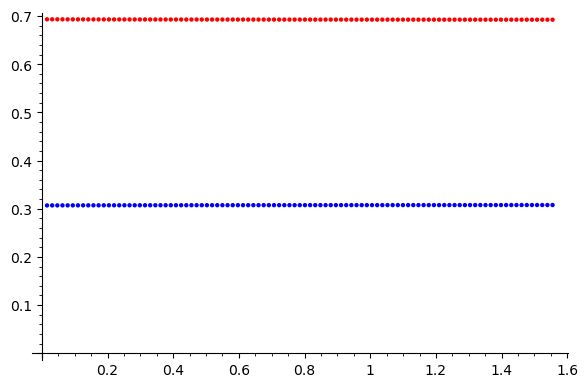

In [74]:
ProporcionesX=[]
ProporcionesY=[]
for j in [1..99]: 
    PobIn=vector(RDF,(cos(j*pi/200),sin(j*pi/200)))
    Pob=M^50*PobIn
    TXt,TYt=Pob[0]/(Pob[0]+Pob[1]),Pob[1]/(Pob[0]+Pob[1])
    ProporcionesX+=[(j*pi/200,TXt)]#Lista de pares (angulo(j),TX_k(angulo(j))) con k=50
    ProporcionesY+=[(j*pi/200,TYt)]#Lista de pares (angulo(j),TY_k(angulo(j))) con k=50
DibujoX=points(ProporcionesX,color='red',xmin=0,xmax=pi/2,ymin=0)
DibujoY=points(ProporcionesY,color='blue',xmin=0,xmax=pi/2,ymin=0)
show(DibujoX+DibujoY)

____________


**Ejercicio 2** 

En una granja de cría de cerdos, los animales son clasificados según sus edades de la siguiente forma:

- Cochinillos: De $0$ a $1$ año.

- Lechones: De 1 a 2 años.

- Jóvenes: De 2 a 3 años.

- Adultos: De 3 a 4 años.

El procedimiento de gestión de las hembras de la granja es el siguiente:

- Se sacrifica al $60\%$ de las que van naciendo para su consumo como cochinillos.

- Se sacrifica para su consumo a todas las hembras cuando llegan a los $4$ años. No se sacrifica a ninguna de las demás, y se supone que ningún animal muere por otras causas.

- Se dedica a todas las hembras jóvenes y adultas a la cría. Se sabe que, en media, cada hembra joven tendrá $0.5$ camadas de $5$ cochinillos, cada hembra adulta tendrá $0.8$ camadas de $5$ cochinillos, y que el $50\%$ de todos los nuevos nacidos serán hembras.

a) Formula el modelo apropiado para describir la evolución de la población de las hembras.

In [75]:
M=matrix(QQ,4,[[0,0,0.5*0.5*5,0.5*0.8*5],[0.4,0,0,0],[0,1,0,0],[0,0,1,0]]) 
PobIn=vector((100,0,0,0)) #Probamos empezando solo con cochinillos (100)
show(M)
print([M^k*PobIn for k in range(5)])##Primeras cinco distribuciones 

[  0   0 5/4   2]
[2/5   0   0   0]
[  0   1   0   0]
[  0   0   1   0]

[(100, 0, 0, 0), (0, 40, 0, 0), (0, 0, 40, 0), (50, 0, 0, 40), (80, 20, 0, 0)]


In [76]:
PobIn=vector((10,10,10,10)) # Y ahora probamos empezando con 10 individuos en cada clase
print([M^k*PobIn for k in range(5)])

[(10, 10, 10, 10), (65/2, 4, 10, 10), (65/2, 13, 4, 10), (25, 13, 13, 4), (97/4, 10, 13, 13)]


b) Comprueba que el autovalor dominante es mayor que 1, y que por tanto la población crece sin límite, por lo que la granja no es sostenible con la tasa de sacrificio dada.    

In [77]:
Dominante=AutovalorDominante(M)
if Dominante:
    print('Existe autovalor dominante, y es: %s'%Dominante)
    if  Dominante>1:
        print('Al ser mayor que 1, la población crece sin límite.')
else:
    print('Esta matriz no tiene valor propio dominante.')

Existe autovalor dominante, y es: 1.075454093552008?
Al ser mayor que 1, la población crece sin límite.


c) Se aumenta la tasa de sacrificio al 80%. Comprobar que el autovalor dominante pasa a ser menor que 1, y que por tanto la población tiende a 0 asintóticamente, de forma que la granja tampoco es sostenible. 

In [78]:
M2=matrix(QQ,4,[[0,0,0.5*0.5*5,0.5*0.8*5],[.2,0,0,0],[0,1,0,0],[0,0,1,0]])
Dominante2=AutovalorDominante(M2)
if Dominante2:
    print('Existe autovalor dominante, y es: %s.'%Dominante2)
    if Dominante2<1:
        print('Al ser menor que 1, la población se extinguirá.')
else:
    print('Esta matriz no tiene valor propio dominante.')

Existe autovalor dominante, y es: 0.8880777493502824?.
Al ser menor que 1, la población se extinguirá.


In [28]:
show(M2)

[  0   0 5/4   2]
[1/5   0   0   0]
[  0   1   0   0]
[  0   0   1   0]

d) Determina una tasa de sacrificio que haga que la granja sea sostenible, esto es, que haga que el  autovalor dominante sea igual a 1. 

**Indicación.** Pon la tasa de sacrificio  $\texttt{t}$  como un parámetro en el lugar adecuado de la matriz (debes decirle a SageMath que $\texttt{t}$ es una variable, para que lo entienda). La matriz, digamos $M_t$, dependerá de un parámetro, y los cálculos en SageMath, al no indicarle ningún anillo, se harán por defecto en el anillo simbólico $\texttt{SR}$. Calcula el polinomio característico 
$$P(x,t)=\texttt{det}(M_t-x*\texttt{identity}\_\texttt{matrix}(4))
\quad\text{ o también}\quad
P(x,t)=\texttt{charpoly}(M_t)
$$
y calcula el $\texttt{t}$ que asegura que $1$ es un autovalor: es decir $P(1,t)==0$. Asegúrate de que $1$ no solo es autovalor, sino que además es el autovalor dominante. 

(El procedimiento $\texttt{.substitute()}$ puede ser útil para, una vez calculado el valor adecuado de $t$, sustituirlo en la matriz $M_t$.)

In [79]:
#Pongamos la tasa como un parámetro y veamos cuándo es 1 un autovalor
t=var('t')
Mt=matrix(4,[[0,0,5/4,2],[t,0,0,0],[0,1,0,0],[0,0,1,0]])
P(x,t)=charpoly(Mt)#charpoly es el polinomio característico = det(Mt-x*identity_matrix(4))
show(Mt)
show(P(x,t))

[  0   0 5/4   2]
[  t   0   0   0]
[  0   1   0   0]
[  0   0   1   0]

x^4 - 5/4*t*x - 2*t

In [81]:
solve(P(1,t)==0, t)#Queremos que x=1 sea una raíz del polinomio característico

[t == (4/13)]

In [82]:
t0=solve(P(1,t),t)[0].rhs()#Para extraer la solución en t
print(t0)

4/13


In [83]:
print('La tasa de sacrificio es %s'%((1-t0)))#La tasa de sacrificio
print('aproximadamente de un %.2f por ciento.'%((1-t0)*100))

La tasa de sacrificio es 9/13
aproximadamente de un 69.23 por ciento.


In [88]:
#Ponemos t=t0 y comprobamos (primero mostrando todos) que 1 es autovalor dominante.
Mestable=matrix(QQ,Mt.substitute(t==t0))
show(Mestable)
print([abs(autovalor) for autovalor in Mestable.eigenvalues()])

[   0    0  5/4    2]
[4/13    0    0    0]
[   0    1    0    0]
[   0    0    1    0]

[1, 0.7550339469839745?, 0.9027969395795628?, 0.9027969395795628?]


In [87]:
#Comprobación del autovalor dominante
Dominante3=AutovalorDominante(Mestable)
if Dominante3:
    print('Existe autovalor dominante, y es: %s.'%Dominante3)
    if Dominante3==1:
        print('Al ser 1 la población se estabiliza asintóticamente.')
else:
    print('Esta matriz no tiene valor propio dominante.')

Existe autovalor dominante, y es: 1.00000000000000.
Al ser 1 la población se estabiliza asintóticamente.


e) Comprueba que con la tasa de sacrificio obtenida en d) la explotación es sostenible, calculando qué datos se obtienen hasta $n=500$.

Comprueba que la población total  se estabiliza a una cantidad no nula y la proporción de individuos por clase se estabiliza según las componentes del autovector normalizado asociado al autovalor dominante. 

In [89]:
show(Mestable)

[   0    0  5/4    2]
[4/13    0    0    0]
[   0    1    0    0]
[   0    0    1    0]

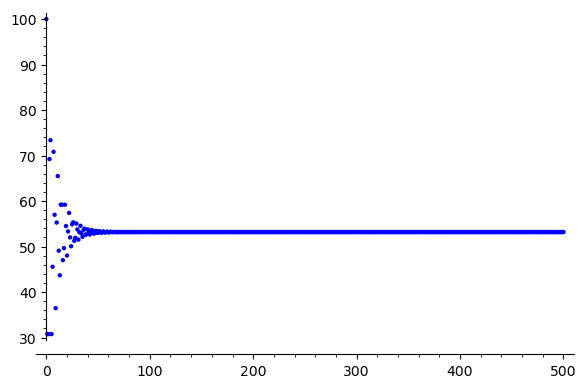

In [36]:
#Veamos qué pasa con la población.
#Calculamos cómo varía la población total
v=vector((100,0,0,0))
Poblacion=[(0,sum(v))]
for j in [1..500]:
    v=Mestable*v
    Poblacion.append((j,sum(v)))

points(Poblacion,color='blue')

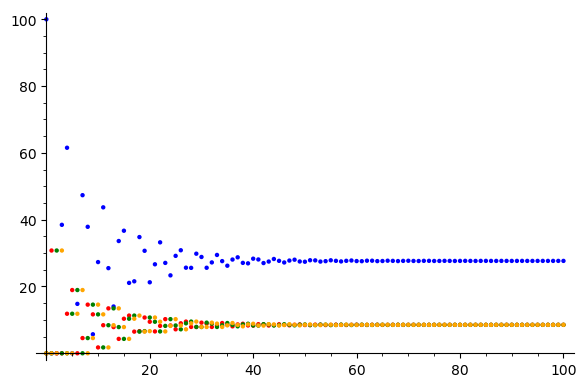

In [37]:
#Para el caso de la población estable, vamos a hacer una gráfica separada para la población de cada clase de edad
#Tomaremos solo 100 iteraciones, para visualizar mejor el comportamiento en los primeros años
v=vector((100,0,0,0))
C, L, J, A=[(0,v[0])],[(0,v[1])],[(0,v[2])],[(0,v[3])]
for j in [1..100]:
    v=Mestable*v
    C.append((j,v[0]))
    L.append((j,v[1]))
    J.append((j,v[2]))
    A.append((j,v[3]))

points(C,color='blue')+points(L,color='red')+points(J,color='green')+points(A,color='orange')

In [38]:
#Tras las variaciones iniciales, acabamos con prácticamente igual número de L, J y A, y con más C.
#Dibujamos los valores concretos y los comparamos con el autovector principal
proporciones=(C[-1][1],L[-1][1],J[-1][1],A[-1][1])
vproporciones=vector(t.n() for t in proporciones)#Conviene solo ver una aproximación numérica
vproporciones=vproporciones/sum(vproporciones)
show(vproporciones)
Dominante3,w=DominanteNormalizado(Mestable)
show(w)
print(w-vproporciones)

(0.520010981909778, 0.160009512222374, 0.159990686297100, 0.159988819570749)

(13/25, 4/25, 4/25, 4/25)

(-0.0000109819097777741, -9.51222237366434e-6, 9.31370290049860e-6, 0.0000111804292511342)


In [39]:
#Efectivamente, la primera componente del autovector principal es 13/4=3.25 veces las otras,
#y esta es la misma relación que está apareciendo entre la población C y las demás tras 100 iteraciones
(13/4).n(), [(proporciones[0]/proporciones[j]).n() for j in [1..3]]

(3.25000000000000, [3.24987542732517, 3.25025783653511, 3.25029576007230])